# Voice of the Customer from Google Reviews
## End-to-End NLP Analysis for Business Insight Extraction

### Business Problem
Google reviews contain rich, unstructured customer feedback. Ratings tell us *how much* customers liked or disliked an experience, but review text explains *why*.

### Why This Matters
By analyzing review language, the business can identify recurring strengths to preserve and recurring pain points to fix. This supports better operational prioritization, service quality improvement, and reputation management.

### Questions Answered
1. What do customers mention most frequently?
2. What themes separate positive vs negative feedback?
3. Which recurring issues are tied to low ratings?
4. How aligned are text sentiment and star ratings?
5. What practical actions should the business take next?

### Notebook Outputs
- Cleaned and standardized review dataset.
- Preprocessed text fields for NLP analysis.
- Sentiment scores and labels.
- Theme discovery using TF-IDF + NMF.
- Positive vs negative language comparison.
- Business insight tables and recommendations.


## Notebook Structure
1. Setup and environment
2. Data load and schema detection
3. Data cleaning and text preprocessing
4. Descriptive review analytics
5. Sentiment analysis
6. Theme discovery
7. Positive vs negative comparison
8. Business insights and recommendations
9. Executive summary and exportable outputs


In [1]:
# Setup
import warnings
warnings.filterwarnings("ignore")

import re
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import NMF

from wordcloud import WordCloud

# Reproducibility and display
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)


### Package Note
This notebook assumes common NLP libraries are available: pandas, numpy, matplotlib, seaborn, nltk, scikit-learn, and wordcloud.
If a package is missing, install it and rerun the notebook from the top.


In [2]:
# Locate and load data
ROOT = Path.cwd()
CANDIDATE_DIRS = [ROOT, ROOT / "data"]


def locate_file(filename: str) -> Path:
    for d in CANDIDATE_DIRS:
        p = d / filename
        if p.exists():
            return p
    raise FileNotFoundError(f"Could not locate {filename} in {CANDIDATE_DIRS}")

DATA_PATH = locate_file("google_review_data.csv")
raw_df = pd.read_csv(DATA_PATH)

print("Loaded file:", DATA_PATH)
print("Shape:", raw_df.shape)
display(raw_df.head(5))


Loaded file: c:\Users\Matt Shaver\OneDrive\Desktop\DSBA-6276-Hornets-Analysis\data\google_review_data.csv
Shape: (500, 10)


,Reviewer,Local Guide,Reviews,Photos,Stars,Review,Date,Visited on,Wait time,Reservation recommended
0,Amanda Stapleton,False,2,1,5,"I've been to many concerts in many venues, but...",an hour ago,NaN,NaN,NaN
1,Kerry L Hodges,True,98,83,5,Really A Nice Facility,4 hours ago,NaN,NaN,NaN
2,Dennis Murdock,True,145,18,4,Great time though I did not like having to mak...,8 hours ago,NaN,NaN,NaN
3,Marcos De Oliveira,True,147,99,5,Great work with the renovations!,15 hours ago,NaN,NaN,NaN
4,Greg Christian,True,384,1322,5,First time at the Spectrum Center to see Eric ...,23 hours ago,NaN,NaN,NaN


In [3]:
# Initial inspection
print("Columns:", list(raw_df.columns))

dtype_df = pd.DataFrame({
    "column": raw_df.columns,
    "dtype": raw_df.dtypes.astype(str).values,
    "missing_count": raw_df.isna().sum().values,
    "missing_pct": (raw_df.isna().mean().values * 100)
}).sort_values("missing_pct", ascending=False)

display(dtype_df)
print("Duplicate rows:", raw_df.duplicated().sum())


Columns: ['Reviewer', 'Local Guide', 'Reviews', 'Photos', 'Stars', 'Review', 'Date', 'Visited on', 'Wait time', 'Reservation recommended']


,column,dtype,missing_count,missing_pct
9,Reservation recommended,str,267,53.400
8,Wait time,str,264,52.800
7,Visited on,str,261,52.200
0,Reviewer,str,0,0.000
1,Local Guide,bool,0,0.000
2,Reviews,int64,0,0.000
5,Review,str,0,0.000
4,Stars,int64,0,0.000
3,Photos,int64,0,0.000
6,Date,str,0,0.000


Duplicate rows: 0


### Inspection Observations
- Review-level fields and metadata fields are present; schema mapping is handled defensively in the next section.
- Missingness appears concentrated in optional metadata fields (for example, wait-time and reservation details), which is common in scraped review data.
- Core analysis fields (review text and stars) will be validated before modeling and interpretation.


In [4]:
# Defensive schema detection

def normalize_col(col: str) -> str:
    col = str(col).strip().lower()
    col = re.sub(r"[^a-z0-9]+", "_", col)
    col = re.sub(r"_+", "_", col).strip("_")
    return col


def find_col(df: pd.DataFrame, candidates):
    norm_map = {normalize_col(c): c for c in df.columns}
    for cand in candidates:
        nc = normalize_col(cand)
        if nc in norm_map:
            return norm_map[nc]
    for nc, orig in norm_map.items():
        for cand in candidates:
            if normalize_col(cand) in nc:
                return orig
    return None

schema = {
    "text_col": find_col(raw_df, ["review", "review_text", "text", "comment", "content", "body"]),
    "rating_col": find_col(raw_df, ["stars", "rating", "score", "star_rating"]),
    "date_col": find_col(raw_df, ["date", "review_date", "created_at", "timestamp", "time"]),
    "reviewer_col": find_col(raw_df, ["reviewer", "author", "user", "name", "reviewer_name"]),
    "title_col": find_col(raw_df, ["title", "review_title", "headline"]),
    "location_col": find_col(raw_df, ["location", "store", "branch", "business", "place"]),
}

schema_df = pd.DataFrame(schema.items(), columns=["logical_field", "mapped_column"])
display(schema_df)

if schema["text_col"] is None:
    raise ValueError("No review text column detected. Please inspect schema mapping logic.")
if schema["rating_col"] is None:
    print("Warning: No rating column detected. Rating-dependent analyses will be limited.")


,logical_field,mapped_column
0,text_col,Review
1,rating_col,Stars
2,date_col,Date
3,reviewer_col,Reviewer
4,title_col,NaN
5,location_col,NaN


### Schema Assumptions Used
- The notebook maps logical fields to available columns using case-insensitive, punctuation-insensitive matching.
- If exact names differ in future exports, the helper mapping should still identify likely text/rating/date fields.
- Analyses requiring a missing field automatically degrade gracefully when possible.


In [5]:
# Data cleaning
work = raw_df.copy()

# Keep only mapped columns plus useful metadata if present
text_col = schema["text_col"]
rating_col = schema["rating_col"]
date_col = schema["date_col"]
reviewer_col = schema["reviewer_col"]

work["review_text_raw"] = work[text_col].fillna("").astype(str).str.strip()

if rating_col is not None:
    work["rating"] = pd.to_numeric(work[rating_col], errors="coerce")
else:
    work["rating"] = np.nan

# Parse date defensively, including relative date strings when possible
if date_col is not None:
    raw_dates = work[date_col].astype(str).fillna("")
    parsed = pd.to_datetime(raw_dates, errors="coerce")

    # Try dateparser for relative strings (e.g., "4 hours ago") if many values are missing
    if parsed.notna().mean() < 0.6:
        try:
            import dateparser
            from datetime import datetime
            parsed2 = raw_dates.apply(lambda x: dateparser.parse(x, settings={"RELATIVE_BASE": datetime.now()}) if isinstance(x, str) and x.strip() else pd.NaT)
            parsed2 = pd.to_datetime(parsed2, errors="coerce")
            parsed = parsed.fillna(parsed2)
        except Exception:
            pass

    work["review_date"] = parsed
else:
    work["review_date"] = pd.NaT

# Optional reviewer
if reviewer_col is not None:
    work["reviewer_name"] = work[reviewer_col].astype(str).str.strip()
else:
    work["reviewer_name"] = "Unknown"

# Remove exact duplicates first
rows_before = len(work)
work = work.drop_duplicates()

# Remove duplicated reviews by key content signals
dedupe_keys = ["review_text_raw"]
if reviewer_col is not None:
    dedupe_keys.append("reviewer_name")
if date_col is not None:
    dedupe_keys.append("review_date")

work = work.drop_duplicates(subset=dedupe_keys, keep="first")

# Remove blank or near-blank text
work["review_text_raw"] = work["review_text_raw"].str.replace(r"\s+", " ", regex=True).str.strip()
work["char_len_raw"] = work["review_text_raw"].str.len()
work = work[(work["review_text_raw"].str.len() >= 5)].copy()

# Standardize ratings to plausible range if available
if work["rating"].notna().any():
    work.loc[(work["rating"] < 1) | (work["rating"] > 5), "rating"] = np.nan

rows_after = len(work)
print(f"Rows before cleaning: {rows_before:,}")
print(f"Rows after cleaning:  {rows_after:,}")
print(f"Rows removed:         {rows_before - rows_after:,}")

display(work[["review_text_raw", "rating", "review_date", "reviewer_name"]].head(5))


Rows before cleaning: 500
Rows after cleaning:  499
Rows removed:         1


,review_text_raw,rating,review_date,reviewer_name
0,"I've been to many concerts in many venues, but...",5.000,NaT,Amanda Stapleton
1,Really A Nice Facility,5.000,NaT,Kerry L Hodges
2,Great time though I did not like having to mak...,4.000,NaT,Dennis Murdock
3,Great work with the renovations!,5.000,NaT,Marcos De Oliveira
4,First time at the Spectrum Center to see Eric ...,5.000,NaT,Greg Christian


### Cleaning Decisions
- Dropped exact duplicate rows and near-duplicate review records when key identifiers match.
- Removed blank/near-blank review text to preserve NLP quality.
- Standardized ratings to numeric values and treated out-of-range ratings as missing.
- Parsed review dates defensively, including fallback parsing for relative date strings when possible.


In [6]:
# Text preprocessing pipeline
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download minimal resources if missing
for pkg in ["stopwords", "wordnet", "omw-1.4", "vader_lexicon"]:
    try:
        nltk.data.find(pkg)
    except Exception:
        nltk.download(pkg, quiet=True)

STOPWORDS = set(stopwords.words("english"))
# Preserve key negations to retain sentiment signal
for token in ["not", "no", "never", "nor"]:
    if token in STOPWORDS:
        STOPWORDS.remove(token)

lemmatizer = WordNetLemmatizer()


def preprocess_text(text: str):
    if not isinstance(text, str):
        text = ""
    text = text.lower().strip()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = [t for t in text.split(" ") if t]
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]
    lemmas = [lemmatizer.lemmatize(t) for t in tokens]

    cleaned = " ".join(lemmas)
    return cleaned, lemmas

preprocessed = work["review_text_raw"].apply(preprocess_text)
work["clean_text"] = preprocessed.apply(lambda x: x[0])
work["tokens"] = preprocessed.apply(lambda x: x[1])
work["word_count"] = work["tokens"].apply(len)
work["char_count"] = work["review_text_raw"].str.len()

display(work[["review_text_raw", "clean_text", "tokens", "word_count"]].head(5))


,review_text_raw,clean_text,tokens,word_count
0,"I've been to many concerts in many venues, but...",many concert many venue staff absolute best ev...,"[many, concert, many, venue, staff, absolute, ...",32
1,Really A Nice Facility,really nice facility,"[really, nice, facility]",3
2,Great time though I did not like having to mak...,great time though not like make dollar deposit...,"[great, time, though, not, like, make, dollar,...",15
3,Great work with the renovations!,great work renovation,"[great, work, renovation]",3
4,First time at the Spectrum Center to see Eric ...,first time spectrum center see eric church las...,"[first, time, spectrum, center, see, eric, chu...",38


### Preprocessing Notes
- Preprocessing is intentionally moderate: enough normalization for analysis, while preserving business meaning.
- Negation terms are retained to avoid losing sentiment cues (for example, “not clean”, “not friendly”).
- Both raw and cleaned text are kept for interpretability and traceability.


Review count: 499
Average rating: 4.212424849699399
Average review word count: 22.56513026052104


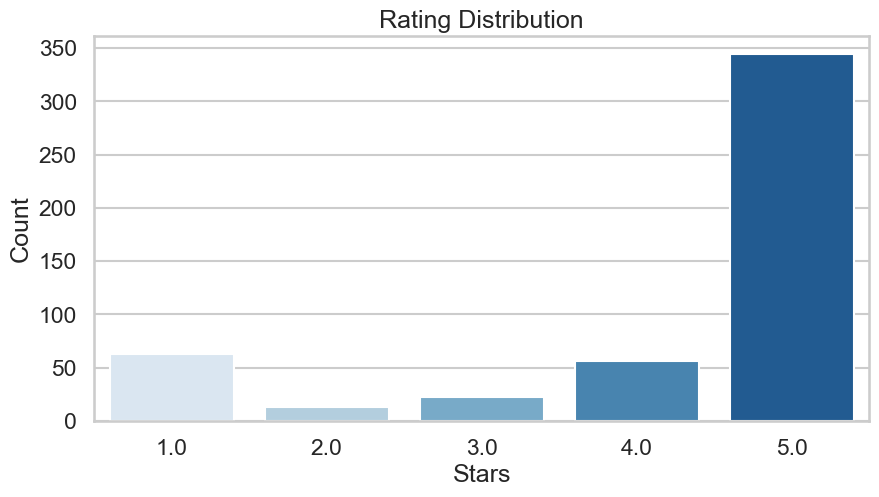

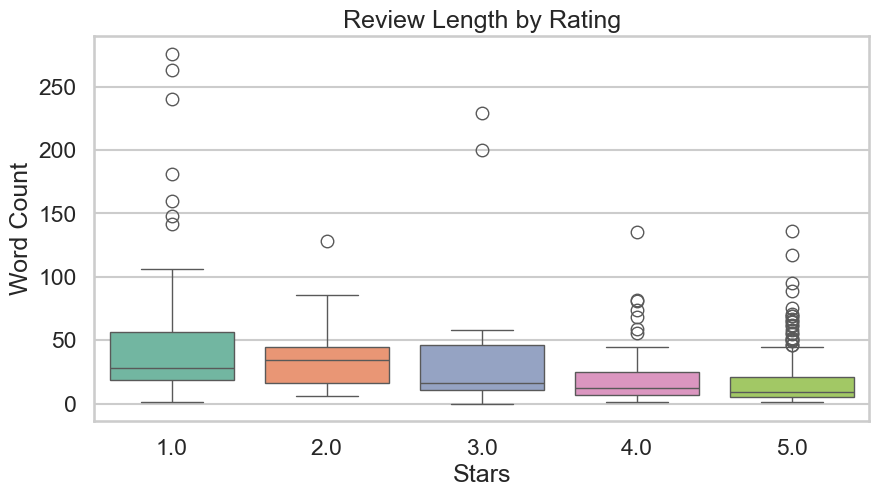

Date trend skipped: insufficient parseable dates.


In [7]:
# Exploratory review analysis
print("Review count:", len(work))
print("Average rating:", work["rating"].mean() if work["rating"].notna().any() else "N/A")
print("Average review word count:", work["word_count"].mean())

# Rating distribution
if work["rating"].notna().any():
    plt.figure(figsize=(10, 5))
    sns.countplot(data=work, x="rating", palette="Blues")
    plt.title("Rating Distribution")
    plt.xlabel("Stars")
    plt.ylabel("Count")
    plt.show()

# Review length by rating
if work["rating"].notna().any():
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=work, x="rating", y="word_count", palette="Set2")
    plt.title("Review Length by Rating")
    plt.xlabel("Stars")
    plt.ylabel("Word Count")
    plt.show()

# Review volume trend over time if dates are usable
if work["review_date"].notna().sum() >= max(20, int(0.15 * len(work))):
    monthly = (
        work.dropna(subset=["review_date"])
        .assign(year_month=lambda d: d["review_date"].dt.to_period("M").dt.to_timestamp())
        .groupby("year_month", as_index=False)
        .size()
        .rename(columns={"size": "review_count"})
    )

    plt.figure(figsize=(12, 5))
    sns.lineplot(data=monthly, x="year_month", y="review_count", marker="o", color="#1f77b4")
    plt.title("Review Volume Over Time")
    plt.xlabel("Month")
    plt.ylabel("Review Count")
    plt.show()
else:
    print("Date trend skipped: insufficient parseable dates.")


Top unigrams


,ngram,count
17,great,199
14,game,136
34,spectrum,127
31,seat,121
37,time,121
6,concert,119
35,staff,118
3,center,118
38,venue,103
28,people,99


Top bigrams


,ngram,count
24,spectrum center,99
19,hornet game,30
17,great time,29
15,great experience,20
18,great venue,19
21,nba game,18
25,staff friendly,15
3,basketball game,13
16,great place,12
8,customer service,12


Top trigrams


,ngram,count
0,bad seat house,5
14,staff friendly helpful,5
4,concert spectrum center,4
1,billie eilish concert,4
19,went hornet game,4
15,time spectrum center,4
7,great concert venue,4
5,game spectrum center,4
13,spectrum center staff,4
2,center nba game,3


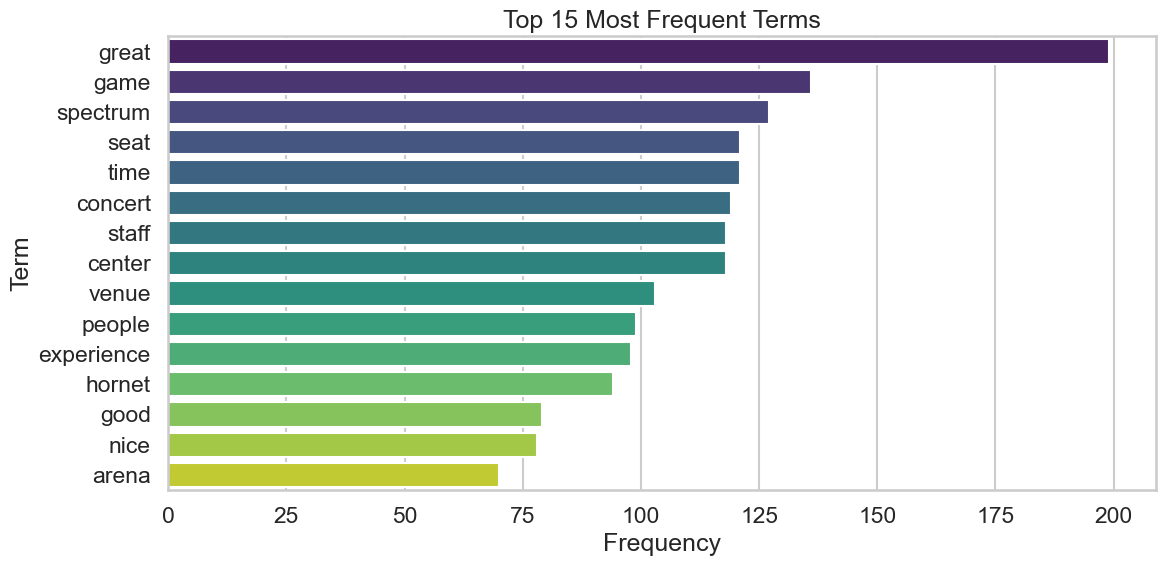

In [8]:
# Most common words, bigrams, trigrams

def top_ngrams(text_series, ngram_range=(1, 1), min_df=3, max_features=50):
    text_series = text_series.fillna("")
    if text_series.str.strip().eq("").all():
        return pd.DataFrame(columns=["ngram", "count"])

    vec = CountVectorizer(ngram_range=ngram_range, min_df=min_df, stop_words="english", max_features=max_features)
    try:
        X = vec.fit_transform(text_series)
    except ValueError:
        vec = CountVectorizer(ngram_range=ngram_range, min_df=1, stop_words="english", max_features=max_features)
        X = vec.fit_transform(text_series)

    counts = np.asarray(X.sum(axis=0)).ravel()
    terms = np.array(vec.get_feature_names_out())
    df = pd.DataFrame({"ngram": terms, "count": counts}).sort_values("count", ascending=False)
    return df

unigram_df = top_ngrams(work["clean_text"], (1, 1), min_df=3, max_features=40)
bigram_df = top_ngrams(work["clean_text"], (2, 2), min_df=3, max_features=30)
trigram_df = top_ngrams(work["clean_text"], (3, 3), min_df=2, max_features=20)

print("Top unigrams")
display(unigram_df.head(20))
print("Top bigrams")
display(bigram_df.head(20))
print("Top trigrams")
display(trigram_df.head(15))

plt.figure(figsize=(12, 6))
sns.barplot(data=unigram_df.head(15), y="ngram", x="count", palette="viridis")
plt.title("Top 15 Most Frequent Terms")
plt.xlabel("Frequency")
plt.ylabel("Term")
plt.tight_layout()
plt.show()


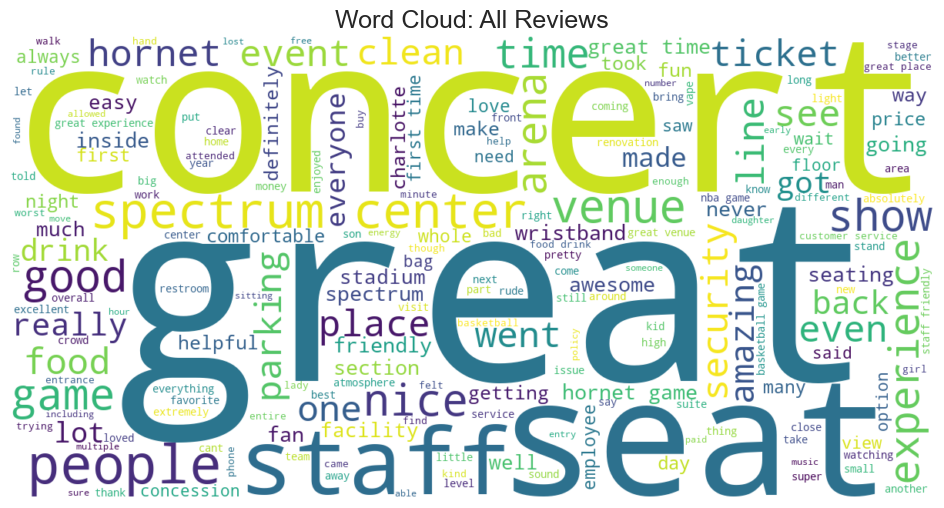

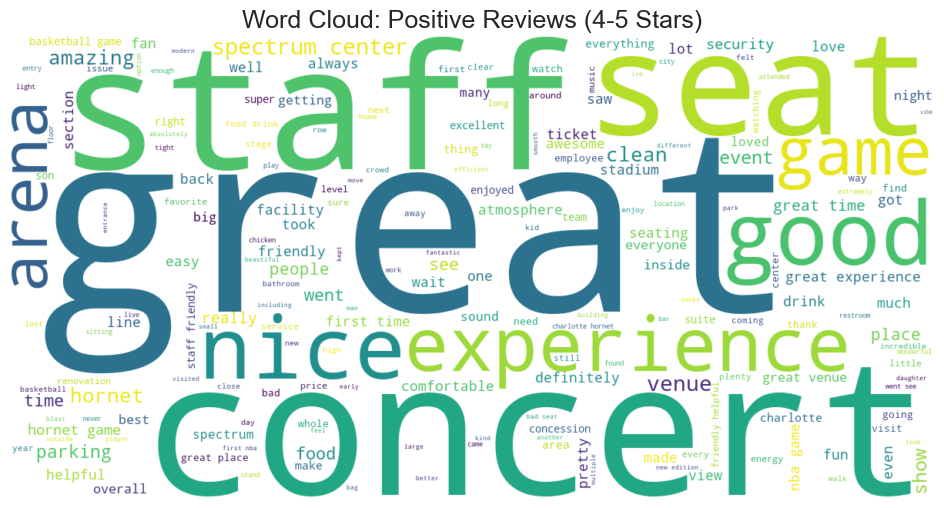

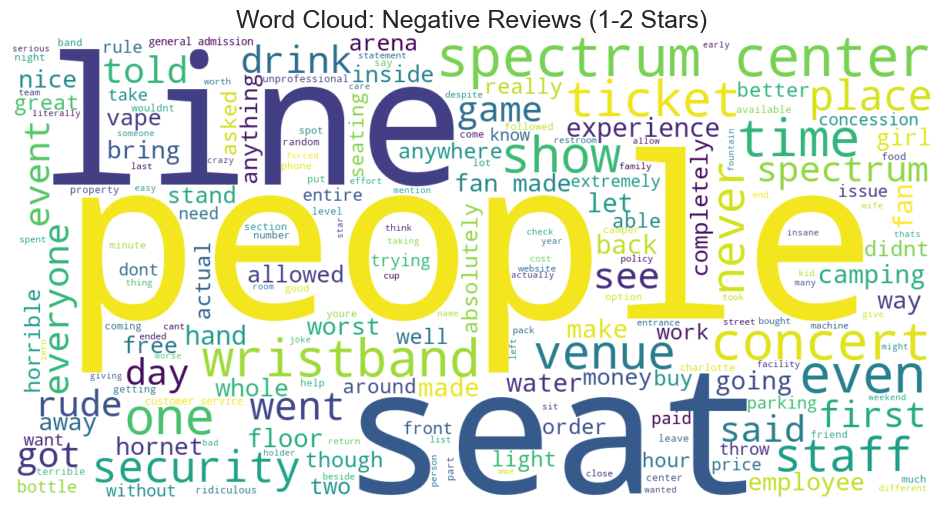

In [9]:
# Word clouds: all, positive, negative

def make_wordcloud(text, title):
    text = " ".join([t for t in text.split() if len(t) > 2])
    if not text.strip():
        print(f"Skipping word cloud for {title}: no text.")
        return

    wc = WordCloud(width=1200, height=600, background_color="white", colormap="viridis").generate(text)
    plt.figure(figsize=(14, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

all_text = " ".join(work["clean_text"].fillna(""))
make_wordcloud(all_text, "Word Cloud: All Reviews")

if work["rating"].notna().any():
    pos_text = " ".join(work.loc[work["rating"] >= 4, "clean_text"].fillna(""))
    neg_text = " ".join(work.loc[work["rating"] <= 2, "clean_text"].fillna(""))
    make_wordcloud(pos_text, "Word Cloud: Positive Reviews (4-5 Stars)")
    make_wordcloud(neg_text, "Word Cloud: Negative Reviews (1-2 Stars)")


### Exploratory Takeaways
- Frequency and n-gram patterns reveal recurring customer language.
- Rating and text-length distributions help contextualize review depth and polarity.
- Word clouds and phrase tables provide quick visibility into dominant conversation areas before formal theme modeling.


In [10]:
# Sentiment analysis (VADER with fallback)
from nltk.sentiment import SentimentIntensityAnalyzer

try:
    sia = SentimentIntensityAnalyzer()

    def get_sentiment_score(text):
        return sia.polarity_scores(text)["compound"]
except Exception:
    # Fallback to TextBlob polarity if VADER is unavailable
    from textblob import TextBlob

    def get_sentiment_score(text):
        return TextBlob(text).sentiment.polarity

work["sentiment_score"] = work["review_text_raw"].fillna("").apply(get_sentiment_score)


def label_sentiment(s):
    if s >= 0.05:
        return "positive"
    if s <= -0.05:
        return "negative"
    return "neutral"

work["sentiment_label"] = work["sentiment_score"].apply(label_sentiment)

display(work[["review_text_raw", "rating", "sentiment_score", "sentiment_label"]].head(10))
print(work["sentiment_label"].value_counts(dropna=False))


,review_text_raw,rating,sentiment_score,sentiment_label
0,"I've been to many concerts in many venues, but...",5.000,0.991,positive
1,Really A Nice Facility,5.000,0.475,positive
2,Great time though I did not like having to mak...,4.000,0.457,positive
3,Great work with the renovations!,5.000,0.659,positive
4,First time at the Spectrum Center to see Eric ...,5.000,0.743,positive
5,Getting in and out isn't bad. There's plenty o...,4.000,0.954,positive
6,Do not get concert tickets here unless you get...,1.000,0.178,positive
7,"First time here; the place is very spacious, t...",5.000,0.882,positive
8,The Spectrum Center staff went above and beyon...,5.000,0.952,positive
9,Go Hornets!! The HIVE was BUZZING last night w...,5.000,0.000,neutral


sentiment_label
positive    385
negative     74
neutral      40
Name: count, dtype: int64


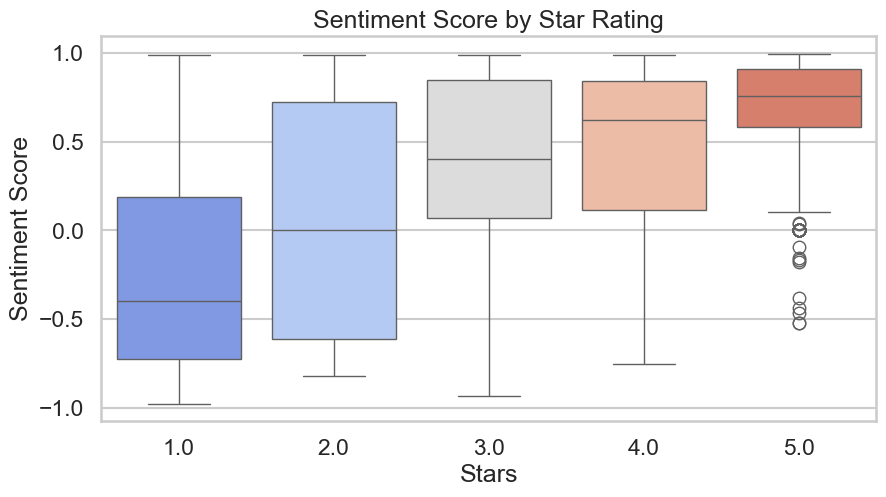

Sentiment label share by rating


sentiment_label,negative,neutral,positive
rating,,,
1.000,0.683,0.032,0.286
2.000,0.462,0.077,0.462
3.000,0.217,0.043,0.739
4.000,0.196,0.054,0.750
5.000,0.026,0.096,0.878


Potential rating-sentiment mismatch reviews: 66


,rating,sentiment_score,sentiment_label,review_text_raw
6,1.000,0.178,positive,Do not get concert tickets here unless you get...
30,5.000,-0.522,negative,It's the Spectrum who doesn't love the Spectru...
38,1.000,0.769,positive,The customer service at this place is horrible...
58,2.000,0.727,positive,"Prior to attending the ACC tournament, I email..."
67,4.000,-0.733,negative,The area between 116 112 is very nice! The big...
76,5.000,-0.153,negative,I miss my Billie.
84,3.000,0.402,positive,There wasn't enough staff visible to help the ...
85,3.000,0.297,positive,Went for the new edition concert. Sound qualit...
87,2.000,0.612,positive,Cup holders are on the floor on the 2nd level ...
101,5.000,-0.522,negative,NIN Whats not to love. The staff there are rea...


In [11]:
# Sentiment vs rating and mismatch analysis
if work["rating"].notna().any():
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=work, x="rating", y="sentiment_score", palette="coolwarm")
    plt.title("Sentiment Score by Star Rating")
    plt.xlabel("Stars")
    plt.ylabel("Sentiment Score")
    plt.show()

    ctab = pd.crosstab(work["rating"], work["sentiment_label"], normalize="index")
    print("Sentiment label share by rating")
    display(ctab)

mismatch = work[
    ((work["rating"] >= 4) & (work["sentiment_label"] == "negative")) |
    ((work["rating"] <= 2) & (work["sentiment_label"] == "positive")) |
    ((work["rating"] == 3) & (work["sentiment_label"] != "neutral"))
].copy() if work["rating"].notna().any() else pd.DataFrame()

print("Potential rating-sentiment mismatch reviews:", len(mismatch))
if len(mismatch) > 0:
    display(mismatch[["rating", "sentiment_score", "sentiment_label", "review_text_raw"]].head(15))


In [12]:
# Theme discovery using TF-IDF + NMF
text_for_topics = work["clean_text"].fillna("")
text_for_topics = text_for_topics[text_for_topics.str.len() >= 5]

if len(text_for_topics) < 20:
    print("Not enough review text for stable topic modeling. Skipping NMF themes.")
    work["topic_id"] = -1
    topic_keywords_df = pd.DataFrame(columns=["topic_id", "keywords"])
else:
    n_topics = 5 if len(text_for_topics) >= 120 else 4

    try:
        tfidf = TfidfVectorizer(max_df=0.90, min_df=5, stop_words="english", ngram_range=(1, 2))
        X_tfidf = tfidf.fit_transform(text_for_topics)
    except ValueError:
        tfidf = TfidfVectorizer(max_df=0.95, min_df=2, stop_words="english", ngram_range=(1, 2))
        X_tfidf = tfidf.fit_transform(text_for_topics)

    nmf = NMF(n_components=n_topics, random_state=SEED, init="nndsvda", max_iter=400)
    W = nmf.fit_transform(X_tfidf)
    H = nmf.components_

    feature_names = np.array(tfidf.get_feature_names_out())

    topic_rows = []
    for i, comp in enumerate(H):
        top_idx = np.argsort(comp)[::-1][:10]
        top_terms = feature_names[top_idx]
        topic_rows.append({
            "topic_id": i,
            "keywords": ", ".join(top_terms)
        })

    topic_keywords_df = pd.DataFrame(topic_rows)

    # Assign dominant topic back to rows used in modeling
    topic_assign = pd.Series(np.argmax(W, axis=1), index=text_for_topics.index)
    work["topic_id"] = -1
    work.loc[topic_assign.index, "topic_id"] = topic_assign.astype(int)

print("Topic keyword summary")
display(topic_keywords_df)


Topic keyword summary


,topic_id,keywords
0,0,"spectrum, center, spectrum center, seat, peopl..."
1,1,"great, great time, great experience, time, exp..."
2,2,"hornet, game, hornet game, arena, loved, food,..."
3,3,"amazing, concert, venue, awesome, amazing expe..."
4,4,"staff, friendly, nice, clean, helpful, staff f..."


In [13]:
# Representative reviews by discovered theme
if "topic_id" in work.columns and (work["topic_id"] >= 0).any():
    rep_rows = []

    # Build tf-idf+nmf document-topic matrix for confidence scores if possible
    valid_idx = work.index[work["topic_id"] >= 0]
    valid_text = work.loc[valid_idx, "clean_text"].fillna("")

    try:
        tfidf_rep = TfidfVectorizer(max_df=0.90, min_df=2, stop_words="english", ngram_range=(1, 2))
        X_rep = tfidf_rep.fit_transform(valid_text)
        n_topics_rep = int(work.loc[valid_idx, "topic_id"].max() + 1)
        nmf_rep = NMF(n_components=n_topics_rep, random_state=SEED, init="nndsvda", max_iter=400)
        W_rep = nmf_rep.fit_transform(X_rep)

        topic_strength = pd.DataFrame(W_rep, index=valid_idx)
        for t in sorted(work.loc[valid_idx, "topic_id"].unique()):
            topic_docs = topic_strength[t].sort_values(ascending=False).head(3).index
            for idx in topic_docs:
                rep_rows.append({
                    "topic_id": int(t),
                    "rating": work.loc[idx, "rating"],
                    "sentiment_label": work.loc[idx, "sentiment_label"],
                    "review_text_raw": work.loc[idx, "review_text_raw"]
                })
    except Exception:
        # Fallback sampling if topic-strength extraction fails
        for t in sorted(work.loc[valid_idx, "topic_id"].unique()):
            sample = work.loc[work["topic_id"] == t, ["rating", "sentiment_label", "review_text_raw"]].head(3)
            for _, row in sample.iterrows():
                rep_rows.append({
                    "topic_id": int(t),
                    "rating": row["rating"],
                    "sentiment_label": row["sentiment_label"],
                    "review_text_raw": row["review_text_raw"]
                })

    representative_reviews = pd.DataFrame(rep_rows)
    display(representative_reviews)
else:
    representative_reviews = pd.DataFrame(columns=["topic_id", "rating", "sentiment_label", "review_text_raw"])
    print("Representative theme reviews skipped: no valid topic assignments.")


,topic_id,rating,sentiment_label,review_text_raw
0,0,5.000,neutral,Big ups spectrum center for the 5 menu!!!
1,0,5.000,neutral,"Spectrum Center, YOU KNOW!!!"
2,0,1.000,negative,Spectrum Center Ignores Accessibility Concerns...
3,1,4.000,positive,Was great
4,1,5.000,positive,The HotWheels Glow and Fire show was great!
5,1,5.000,positive,Great time
6,2,5.000,neutral,Hornets
7,2,5.000,neutral,Go Hornets!
8,2,4.000,neutral,go hornets!
9,3,5.000,positive,Very Great experience


Top words in positive reviews


,term,count
80,great,187
75,game,118
178,time,88
165,staff,87
61,experience,82
85,hornet,82
35,concert,81
151,seat,80
163,spectrum,74
182,venue,71


Top words in negative reviews


,term,count
125,people,60
151,spectrum,45
27,center,38
102,line,35
144,seat,34
34,concert,28
196,wristband,27
168,time,27
154,staff,25
167,ticket,24


Top bigrams in positive reviews


,term,count
160,spectrum center,59
80,great time,29
85,hornet game,27
75,great experience,20
115,nba game,17
81,great venue,16
163,staff friendly,14
22,basketball game,13
77,great place,12
63,friendly helpful,11


Top bigrams in negative reviews


,term,count
160,spectrum center,32
122,general admission,7
106,customer service,7
21,alternate governor,4
117,fan wristband,4
154,security people,4
164,staff member,4
180,wrist band,4
132,make sure,4
125,hornet game,3


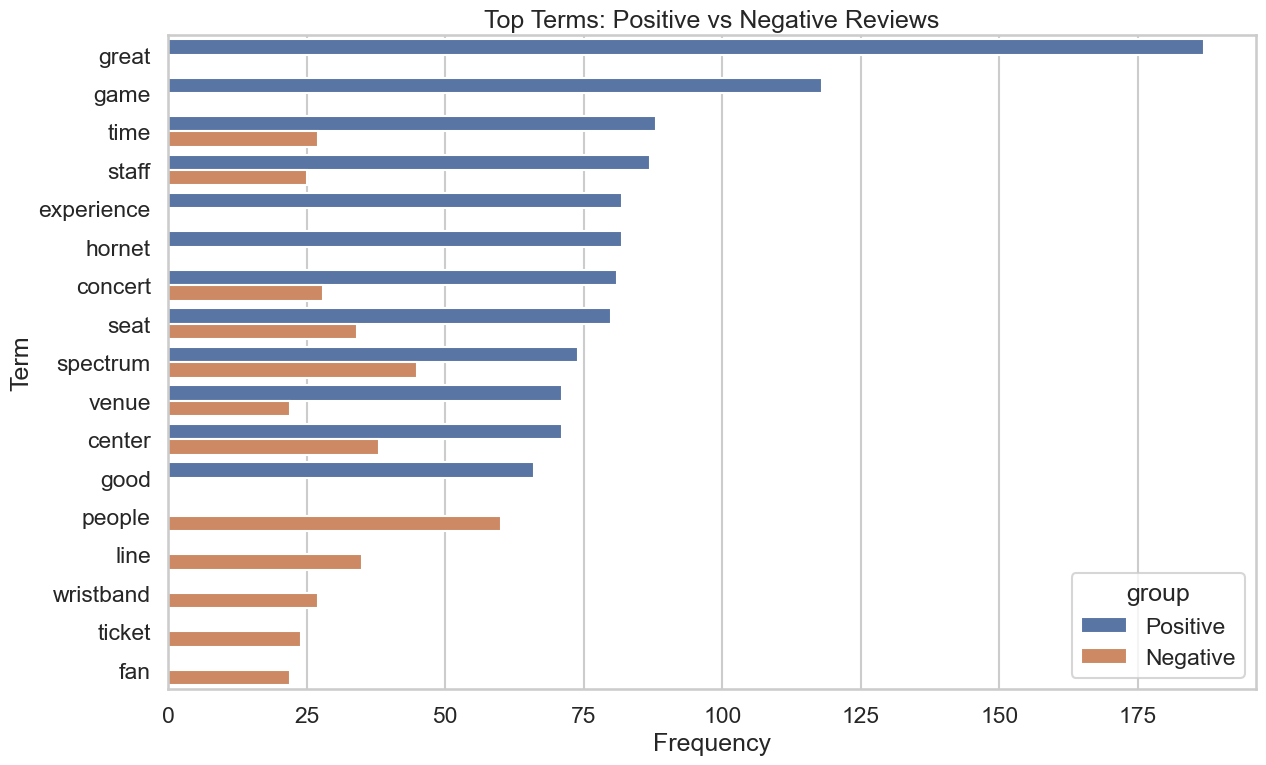

In [14]:
# Positive vs negative text comparison
if work["rating"].notna().any():
    pos_reviews = work[work["rating"] >= 4].copy()
    neg_reviews = work[work["rating"] <= 2].copy()
else:
    pos_reviews = work[work["sentiment_label"] == "positive"].copy()
    neg_reviews = work[work["sentiment_label"] == "negative"].copy()


def top_terms_for_group(df_group, ngram_range=(1, 1), top_n=20):
    if len(df_group) == 0:
        return pd.DataFrame(columns=["term", "count"])
    vec = CountVectorizer(stop_words="english", ngram_range=ngram_range, min_df=1, max_features=200)
    X = vec.fit_transform(df_group["clean_text"].fillna(""))
    counts = np.asarray(X.sum(axis=0)).ravel()
    terms = np.array(vec.get_feature_names_out())
    out = pd.DataFrame({"term": terms, "count": counts}).sort_values("count", ascending=False).head(top_n)
    return out

pos_terms = top_terms_for_group(pos_reviews, (1, 1), 20)
neg_terms = top_terms_for_group(neg_reviews, (1, 1), 20)
pos_bigrams = top_terms_for_group(pos_reviews, (2, 2), 15)
neg_bigrams = top_terms_for_group(neg_reviews, (2, 2), 15)

print("Top words in positive reviews")
display(pos_terms)
print("Top words in negative reviews")
display(neg_terms)
print("Top bigrams in positive reviews")
display(pos_bigrams)
print("Top bigrams in negative reviews")
display(neg_bigrams)

# Side-by-side chart
plot_pos = pos_terms.head(12).copy()
plot_pos["group"] = "Positive"
plot_neg = neg_terms.head(12).copy()
plot_neg["group"] = "Negative"
plot_terms = pd.concat([plot_pos, plot_neg], ignore_index=True)

plt.figure(figsize=(13, 8))
sns.barplot(data=plot_terms, y="term", x="count", hue="group", orient="h")
plt.title("Top Terms: Positive vs Negative Reviews")
plt.xlabel("Frequency")
plt.ylabel("Term")
plt.tight_layout()
plt.show()


In [15]:
# Business insight extraction using interpretable keyword themes
# Theme dictionary is generic and only used as a lens over discovered language.
THEME_KEYWORDS = {
    "customer_service": ["staff", "service", "friendly", "helpful", "rude", "manager", "employee"],
    "cleanliness": ["clean", "dirty", "bathroom", "restroom", "trash", "smell"],
    "pricing_value": ["price", "expensive", "cost", "overpriced", "value", "deposit", "fee"],
    "experience_atmosphere": ["atmosphere", "vibe", "experience", "music", "concert", "crowd"],
    "speed_wait_time": ["wait", "line", "slow", "quick", "fast", "delay"],
    "food_beverage": ["food", "drink", "snack", "bar", "beer", "menu"],
    "access_parking": ["parking", "traffic", "location", "entry", "exit", "seat"],
    "quality_consistency": ["quality", "consistent", "always", "never", "better", "worse"]
}


def has_any_term(text: str, term_list):
    txt = f" {str(text)} "
    for term in term_list:
        if f" {term} " in txt:
            return 1
    return 0

for theme, terms in THEME_KEYWORDS.items():
    work[f"theme_{theme}"] = work["clean_text"].apply(lambda t: has_any_term(t, terms))

theme_cols = [c for c in work.columns if c.startswith("theme_")]

summary_rows = []
for c in theme_cols:
    theme_name = c.replace("theme_", "")
    overall_rate = work[c].mean()

    if work["rating"].notna().any():
        low_rate = work.loc[work["rating"] <= 2, c].mean() if (work["rating"] <= 2).any() else np.nan
        high_rate = work.loc[work["rating"] >= 4, c].mean() if (work["rating"] >= 4).any() else np.nan
    else:
        low_rate = work.loc[work["sentiment_label"] == "negative", c].mean() if (work["sentiment_label"] == "negative").any() else np.nan
        high_rate = work.loc[work["sentiment_label"] == "positive", c].mean() if (work["sentiment_label"] == "positive").any() else np.nan

    gap = low_rate - high_rate if pd.notna(low_rate) and pd.notna(high_rate) else np.nan
    summary_rows.append({
        "theme": theme_name,
        "overall_mention_rate": overall_rate,
        "low_rating_mention_rate": low_rate,
        "high_rating_mention_rate": high_rate,
        "low_minus_high_gap": gap
    })

theme_summary = pd.DataFrame(summary_rows).sort_values("overall_mention_rate", ascending=False)
display(theme_summary)

# Extract top strengths and complaints based on mention-rate patterns
strengths = theme_summary.sort_values("high_rating_mention_rate", ascending=False).head(5)
complaints = theme_summary.sort_values("low_minus_high_gap", ascending=False).head(5)

print("Top strength themes")
display(strengths[["theme", "high_rating_mention_rate", "overall_mention_rate"]])

print("Top complaint-linked themes")
display(complaints[["theme", "low_rating_mention_rate", "high_rating_mention_rate", "low_minus_high_gap"]])


,theme,overall_mention_rate,low_rating_mention_rate,high_rating_mention_rate,low_minus_high_gap
3,experience_atmosphere,0.351,0.289,0.365,-0.076
0,customer_service,0.293,0.395,0.273,0.122
6,access_parking,0.261,0.303,0.250,0.053
5,food_beverage,0.176,0.237,0.165,0.072
1,cleanliness,0.130,0.092,0.140,-0.048
7,quality_consistency,0.128,0.329,0.087,0.241
4,speed_wait_time,0.122,0.289,0.092,0.197
2,pricing_value,0.072,0.158,0.048,0.110


Top strength themes


,theme,high_rating_mention_rate,overall_mention_rate
3,experience_atmosphere,0.365,0.351
0,customer_service,0.273,0.293
6,access_parking,0.250,0.261
5,food_beverage,0.165,0.176
1,cleanliness,0.140,0.130


Top complaint-linked themes


,theme,low_rating_mention_rate,high_rating_mention_rate,low_minus_high_gap
7,quality_consistency,0.329,0.087,0.241
4,speed_wait_time,0.289,0.092,0.197
0,customer_service,0.395,0.273,0.122
2,pricing_value,0.158,0.048,0.110
5,food_beverage,0.237,0.165,0.072


In [16]:
# Optional advanced analyses supported by this dataset
advanced_outputs = {}

# 1) Sentiment trend over time (if parseable dates exist)
if work["review_date"].notna().sum() >= max(20, int(0.15 * len(work))):
    sentiment_time = (
        work.dropna(subset=["review_date"])
        .assign(year_month=lambda d: d["review_date"].dt.to_period("M").dt.to_timestamp())
        .groupby("year_month", as_index=False)["sentiment_score"]
        .mean()
        .rename(columns={"sentiment_score": "avg_sentiment"})
    )

    plt.figure(figsize=(12, 5))
    sns.lineplot(data=sentiment_time, x="year_month", y="avg_sentiment", marker="o", color="#d62728")
    plt.title("Average Sentiment Over Time")
    plt.xlabel("Month")
    plt.ylabel("Average Sentiment")
    plt.show()

    advanced_outputs["sentiment_time"] = sentiment_time
else:
    print("Sentiment trend skipped: insufficient parseable dates.")

# 2) Local Guide vs non-Local Guide comparison if available
local_guide_col = find_col(work, ["local guide", "local_guide", "guide"])
if local_guide_col is not None:
    tmp = work.copy()
    tmp["is_local_guide"] = tmp[local_guide_col].astype(str).str.lower().isin(["true", "1", "yes"])
    guide_stats = tmp.groupby("is_local_guide", as_index=False).agg(
        review_count=("review_text_raw", "count"),
        avg_rating=("rating", "mean"),
        avg_sentiment=("sentiment_score", "mean"),
        avg_word_count=("word_count", "mean")
    )
    print("Local Guide comparison")
    display(guide_stats)
    advanced_outputs["guide_stats"] = guide_stats
else:
    print("Local Guide comparison skipped: no matching column detected.")


Sentiment trend skipped: insufficient parseable dates.
Local Guide comparison


,is_local_guide,review_count,avg_rating,avg_sentiment,avg_word_count
0,False,94,3.574,0.279,25.745
1,True,405,4.360,0.549,21.827


In [17]:
# Actionable recommendations generated from findings

# Build concise recommendation table
recommendation_rows = []
for _, row in complaints.head(5).iterrows():
    recommendation_rows.append({
        "priority": "High",
        "focus_area": row["theme"],
        "evidence": f"Low-vs-high mention gap: {row['low_minus_high_gap']:.3f}",
        "recommended_action": f"Investigate root causes in {row['theme']} and implement an operations improvement plan with weekly monitoring."
    })

for _, row in strengths.head(3).iterrows():
    recommendation_rows.append({
        "priority": "Medium",
        "focus_area": row["theme"],
        "evidence": f"High-rating mention rate: {row['high_rating_mention_rate']:.3f}",
        "recommended_action": f"Preserve and promote {row['theme']} in marketing and staff training playbooks."
    })

recommendations_df = pd.DataFrame(recommendation_rows)
display(recommendations_df)


,priority,focus_area,evidence,recommended_action
0,High,quality_consistency,Low-vs-high mention gap: 0.241,Investigate root causes in quality_consistency...
1,High,speed_wait_time,Low-vs-high mention gap: 0.197,Investigate root causes in speed_wait_time and...
2,High,customer_service,Low-vs-high mention gap: 0.122,Investigate root causes in customer_service an...
3,High,pricing_value,Low-vs-high mention gap: 0.110,Investigate root causes in pricing_value and i...
4,High,food_beverage,Low-vs-high mention gap: 0.072,Investigate root causes in food_beverage and i...
5,Medium,experience_atmosphere,High-rating mention rate: 0.365,Preserve and promote experience_atmosphere in ...
6,Medium,customer_service,High-rating mention rate: 0.273,Preserve and promote customer_service in marke...
7,Medium,access_parking,High-rating mention rate: 0.250,Preserve and promote access_parking in marketi...


In [18]:
# Executive summary and presentation support tables

# Top 5 positive/negative terms for summary
top_pos_terms = pos_terms.head(5)["term"].tolist() if 'pos_terms' in globals() and len(pos_terms) > 0 else []
top_neg_terms = neg_terms.head(5)["term"].tolist() if 'neg_terms' in globals() and len(neg_terms) > 0 else []

exec_summary = pd.DataFrame({
    "summary_component": [
        "Top positive themes (from high-rating mentions)",
        "Top negative themes (from low-vs-high mention gap)",
        "Most frequent positive terms",
        "Most frequent negative terms",
        "Priority opportunity"
    ],
    "details": [
        ", ".join(strengths["theme"].head(5).tolist()) if 'strengths' in globals() else "N/A",
        ", ".join(complaints["theme"].head(5).tolist()) if 'complaints' in globals() else "N/A",
        ", ".join(top_pos_terms) if len(top_pos_terms) else "N/A",
        ", ".join(top_neg_terms) if len(top_neg_terms) else "N/A",
        recommendations_df.iloc[0]["recommended_action"] if len(recommendations_df) else "N/A"
    ]
})

display(exec_summary)

# Representative positive and negative reviews for slides
rep_pos_reviews = work.sort_values("sentiment_score", ascending=False).head(10)[["rating", "sentiment_score", "review_text_raw"]]
rep_neg_reviews = work.sort_values("sentiment_score", ascending=True).head(10)[["rating", "sentiment_score", "review_text_raw"]]

print("Representative positive reviews")
display(rep_pos_reviews)
print("Representative negative reviews")
display(rep_neg_reviews)

# Export presentation-support artifacts
theme_summary.to_csv("google_reviews_theme_summary.csv", index=False)
recommendations_df.to_csv("google_reviews_recommendations.csv", index=False)
exec_summary.to_csv("google_reviews_executive_summary.csv", index=False)
rep_pos_reviews.to_csv("google_reviews_representative_positive.csv", index=False)
rep_neg_reviews.to_csv("google_reviews_representative_negative.csv", index=False)
if len(representative_reviews) > 0:
    representative_reviews.to_csv("google_reviews_topic_representative_reviews.csv", index=False)
if 'mismatch' in globals() and len(mismatch) > 0:
    mismatch.to_csv("google_reviews_sentiment_rating_mismatch.csv", index=False)

print("Exported presentation support CSV files to current working directory.")


,summary_component,details
0,Top positive themes (from high-rating mentions),"experience_atmosphere, customer_service, acces..."
1,Top negative themes (from low-vs-high mention ...,"quality_consistency, speed_wait_time, customer..."
2,Most frequent positive terms,"great, game, time, staff, experience"
3,Most frequent negative terms,"people, spectrum, center, line, seat"
4,Priority opportunity,Investigate root causes in quality_consistency...


Representative positive reviews


,rating,sentiment_score,review_text_raw
355,5.000,0.998,I drove me and my daughter 5 12 hrs one way to...
122,5.000,0.997,We visited the Spectrum Center to watch the Ho...
364,5.000,0.996,Attending the recent NBA game at the Spectrum ...
120,3.000,0.991,"Saw NIN at the Spectrum Center last night, the..."
34,4.000,0.991,Attended multiple concerts and shows here and ...
107,5.000,0.991,This should be a 500 star review. I was at Spe...
0,5.000,0.991,"I've been to many concerts in many venues, but..."
382,5.000,0.989,Rauw Alejandro was AMAZING!! You go here for t...
455,3.000,0.989,We have been going to the spectrum Center for ...
346,5.000,0.989,I went to a Hornets game at Spectrum Center an...


Representative negative reviews


,rating,sentiment_score,review_text_raw
246,1.000,-0.977,The arena itself? Its nice. Getting in? Its li...
441,1.000,-0.973,I think it's very selfish to make fans buy tic...
400,1.000,-0.969,Made me throw my cigarettes out??? A grown 50 ...
317,1.000,-0.962,Allowing a random unqualified fan A NON EMPLOY...
408,1.000,-0.961,Spectrum Center Ignores Accessibility Concerns...
396,3.000,-0.936,"Went to three shows in February- Mary J, Marti..."
43,1.000,-0.903,It is a nice place but It was a very bad exper...
375,3.000,-0.900,"Venue is good, the ladies at the front door di..."
151,1.000,-0.894,"So, Im going to the Ghost concert this Sunday...."
285,1.000,-0.878,"2 tickets, 1000, never got seated due to peopl..."


Exported presentation support CSV files to current working directory.


## Executive Summary (Narrative)
- The review corpus reveals recurring experience drivers that can be quantified through text themes and sentiment.
- Positive feedback patterns indicate strengths to preserve and feature in customer messaging.
- Negative-review language highlights concentrated operational pain points that are feasible to prioritize.
- Sentiment-rating mismatches provide qualitative signals for nuanced service recovery and reputation response strategy.
- The exported summary and recommendation tables can be used directly in presentation slides and decision discussions.
